Phase 1

In [21]:
####### 1- imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
##### 2- connexion MySQL
import mysql.connector

connection = mysql.connector.connect(
    host="localhost",
    user="Dian-Data",
    password="dian_data_2026",
    database="ashrae_energy"
)

print("Verbindung erfolgreich")

Verbindung erfolgreich


Phase 2 : Da train_full mehr als 20 Millionen Zeilen enthält, werden wir nicht die gesamte Tabelle in Python laden.

Für den Anfang verwenden wir eine zufällige Stichprobe von 100.000 Beobachtungen:

In [23]:
query = """
SELECT
    building_id,
    meter,
    meter_reading,
    primary_use
FROM ashrae_energy.train_full
ORDER BY RAND()
LIMIT 100000;
"""

df_stat = pd.read_sql(query, connection)

print("Anzahl der Zeilen:", len(df_stat))
print("Anzahl der Spalten:", len(df_stat.columns))

C:\Users\MamadouDianDiallo\AppData\Local\Temp\ipykernel_6860\2486103122.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_stat = pd.read_sql(query, connection)


Anzahl der Zeilen: 100000
Anzahl der Spalten: 4


In [24]:
df_stat["meter_reading"].describe()

count    1.000000e+05
mean     1.635044e+03
std      1.249311e+05
min      0.000000e+00
25%      1.815000e+01
50%      7.877370e+01
75%      2.662587e+02
max      1.834790e+07
Name: meter_reading, dtype: float64

In [25]:


stat_building = (
    df_stat
    .groupby("primary_use")["meter_reading"]
    .agg(
        Anzahl="count",
        Mittelwert="mean",
        Median="median",
        Standardabweichung="std",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
    .sort_values("Mittelwert", ascending=False)
)

stat_building

,Anzahl,Mittelwert,Median,Standardabweichung,Q1,Q3
primary_use,,,,,,
Education,40451,3422.637238,107.05000,196376.892604,26.000000,370.590500
Services,504,3338.545325,93.89450,14049.384835,39.000000,146.000000
Healthcare,1965,725.321268,199.00000,1403.373283,31.000000,727.289000
Office,21668,549.268890,76.64135,3794.338173,19.000000,253.856500
Utility,273,455.429564,155.15000,677.824428,57.277500,604.054000
Entertainment/public assembly,11318,345.587229,47.54810,4130.233333,8.000000,215.236000
Manufacturing/industrial,582,318.529231,103.85300,563.354088,19.510000,303.755000
Food sales and service,536,289.145140,95.40500,484.603867,46.159375,277.398500
Lodging/residential,10548,277.906373,67.76660,1012.421537,20.511250,196.571750


<Figure size 1200x800 with 0 Axes>

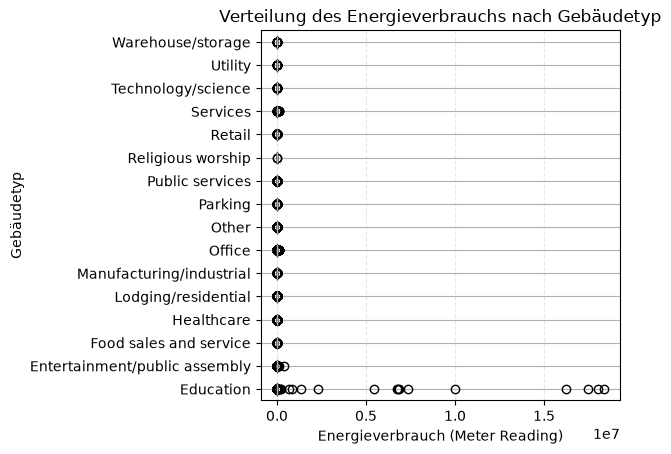

In [26]:
## Visualisierung der Verteilung

plt.figure(figsize=(12, 8))

df_stat.boxplot(
    column="meter_reading",
    by="primary_use",
    vert=False
)

plt.xlabel("Energieverbrauch (Meter Reading)")
plt.ylabel("Gebäudetyp")
plt.title("Verteilung des Energieverbrauchs nach Gebäudetyp")
plt.suptitle("")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
## Test de Kruskal-Wallis

from scipy.stats import kruskal

In [28]:
# Daten nach Gebäudetyp gruppieren

groups = [
    group["meter_reading"].dropna().values
    for _, group in df_stat.groupby("primary_use")
]

# Kruskal-Wallis-Test

statistic, p_value = kruskal(*groups)

print("Kruskal-Wallis Statistik:", statistic)
print("p-Wert:", p_value)

Kruskal-Wallis Statistik: 3132.2270615109674
p-Wert: 0.0


„Der Kruskal-Wallis-Test zeigt einen statistisch signifikanten Unterschied im Energieverbrauch zwischen den Gebäudetypen (H = 3027,96; p < 0,05).“

In [29]:
## Post-hoc-Test

%pip install scikit-posthocs

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
## Import
import scikit_posthocs as sp

In [31]:
## Test
posthoc = sp.posthoc_dunn(
    df_stat,
    val_col="meter_reading",
    group_col="primary_use",
    p_adjust="holm"
)

posthoc

,Education,Entertainment/public assembly,Food sales and service,Healthcare,Lodging/residential,Manufacturing/industrial,Office,Other,Parking,Public services,Religious worship,Retail,Services,Technology/science,Utility,Warehouse/storage
Education,1.000000e+00,2.435036e-206,1.000000e+00,2.356397e-22,9.801064e-89,1.000000e+00,3.421220e-67,3.913454e-181,1.087650e-57,7.650200e-140,1.643907e-60,2.087962e-47,2.228910e-01,4.859438e-03,1.817197e-08,5.882279e-54
Entertainment/public assembly,2.435036e-206,1.000000e+00,1.778469e-16,6.196698e-115,1.675810e-13,3.026038e-15,4.253527e-52,2.513594e-62,4.427447e-07,1.000000e+00,2.246960e-34,3.650150e-10,3.835453e-05,7.602782e-02,7.519494e-29,5.849983e-14
Food sales and service,1.000000e+00,1.778469e-16,1.000000e+00,6.035050e-03,1.266262e-08,1.000000e+00,7.419583e-05,7.829807e-65,6.625355e-25,1.582436e-14,2.316153e-51,1.178283e-27,1.286097e-01,5.072001e-03,4.181554e-04,7.150179e-32
Healthcare,2.356397e-22,6.196698e-115,6.035050e-03,1.000000e+00,1.331111e-74,3.582106e-04,3.012667e-57,2.681042e-188,2.967085e-82,5.163792e-101,1.401083e-77,1.266536e-70,3.650150e-10,7.030724e-13,3.093881e-01,1.929524e-77
Lodging/residential,9.801064e-89,1.675810e-13,1.266262e-08,1.331111e-74,1.000000e+00,1.632427e-07,3.097934e-08,1.524332e-90,2.277919e-17,1.632427e-07,6.985269e-42,7.656399e-19,1.853402e-01,1.000000e+00,9.479256e-21,1.172110e-23
Manufacturing/industrial,1.000000e+00,3.026038e-15,1.000000e+00,3.582106e-04,1.632427e-07,1.000000e+00,6.289492e-04,3.192359e-64,1.172110e-23,2.649803e-13,3.809663e-50,2.014122e-26,3.093881e-01,1.951402e-02,5.577185e-05,1.261412e-30
Office,3.421220e-67,4.253527e-52,7.419583e-05,3.012667e-57,3.097934e-08,6.289492e-04,1.000000e+00,1.185531e-119,1.680728e-28,1.063436e-32,8.118369e-48,4.122534e-27,1.000000e+00,1.000000e+00,3.291449e-16,1.331254e-32
Other,3.913454e-181,2.513594e-62,7.829807e-65,2.681042e-188,1.524332e-90,3.192359e-64,1.185531e-119,1.000000e+00,6.338328e-13,4.972191e-65,6.949463e-08,4.181554e-04,2.403447e-41,2.642168e-28,1.213773e-71,3.870130e-02
Parking,1.087650e-57,4.427447e-07,6.625355e-25,2.967085e-82,2.277919e-17,1.172110e-23,1.680728e-28,6.338328e-13,1.000000e+00,1.942682e-08,1.971839e-20,3.823997e-01,4.178531e-12,6.735485e-07,3.294914e-37,2.957668e-02
Public services,7.650200e-140,1.000000e+00,1.582436e-14,5.163792e-101,1.632427e-07,2.649803e-13,1.063436e-32,4.972191e-65,1.942682e-08,1.000000e+00,1.373735e-35,1.948066e-11,3.582106e-04,2.175345e-01,5.692899e-27,2.372097e-15


### Conclusion – Test de Dunn post-hoc
Der Dunn-Post-hoc-Test mit Holm-Korrektur zeigt, dass sich der Energieverbrauch zwischen mehreren Gebäudetypen statistisch signifikant unterscheidet.

Bei einem Signifikanzniveau von α = 0,05 weisen einige Gebäudetypen signifikante Unterschiede auf, während andere Paarvergleiche keine signifikanten Unterschiede zeigen.

Beispielsweise unterscheiden sich Education und Office statistisch signifikant voneinander (p < 0,001). Zwischen Education und Services wurde dagegen kein signifikanter Unterschied festgestellt (p = 1,00).

Damit bestätigt die Post-hoc-Analyse, dass der im Kruskal-Wallis-Test festgestellte Unterschied nicht für alle Gebäudetypen gleichermaßen gilt, sondern insbesondere zwischen bestimmten Gruppen besteht.

In [32]:
# Effektstärke: Epsilon-Quadrat

n = len(df_stat)
k = df_stat["primary_use"].nunique()
H = statistic

epsilon_squared = (H - k + 1) / (n - k)

print("Epsilon-Quadrat:", epsilon_squared)

Epsilon-Quadrat: 0.03117725897654592


„Der Kruskal-Wallis-Test zeigt statistisch signifikante Unterschiede im Energieverbrauch zwischen den Gebäudetypen (H = 3027,96; p < 0,05). Der anschließende Dunn-Post-hoc-Test zeigt, dass sich mehrere Gebäudetypen signifikant voneinander unterscheiden. Die Effektstärke von ε² = 0,030 weist jedoch auf einen relativ kleinen bis moderaten Gesamteffekt hin.“

In [35]:
# Daten für die Korrelationsanalyse laden

query_corr = """
SELECT
    square_feet,
    meter_reading
FROM ashrae_energy.train_full
WHERE square_feet IS NOT NULL
  AND meter_reading IS NOT NULL
ORDER BY RAND()
LIMIT 100000;
"""

df_corr = pd.read_sql(query_corr, connection)

print("Anzahl der Beobachtungen:", len(df_corr))
print(df_corr.head())

C:\Users\MamadouDianDiallo\AppData\Local\Temp\ipykernel_6860\124137691.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_corr = pd.read_sql(query_corr, connection)


Anzahl der Beobachtungen: 100000
   square_feet  meter_reading
0        42755           0.00
1       325217         690.28
2       155100         166.29
3        70042         530.04
4          898           2.24


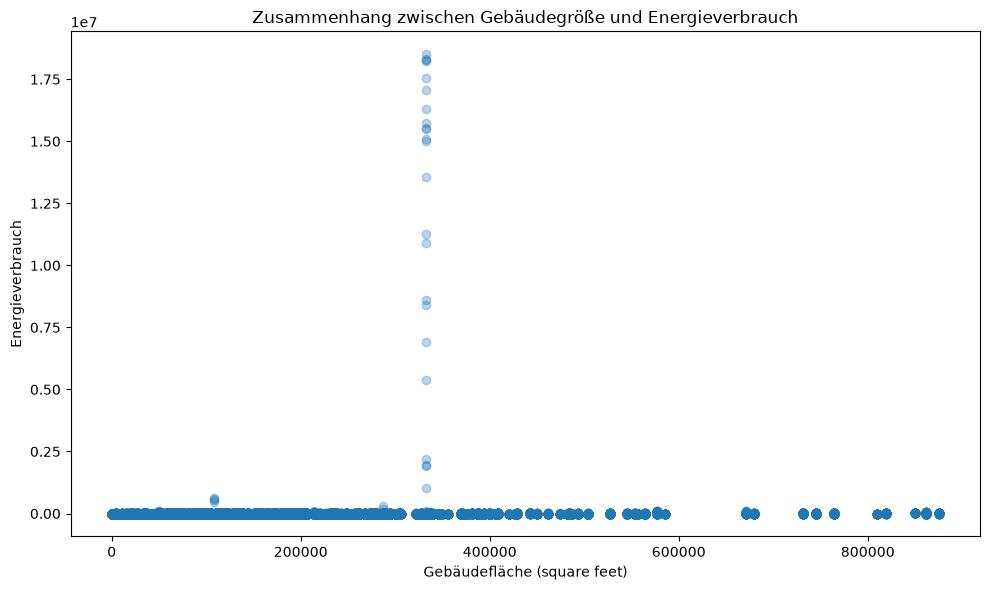

In [37]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_corr["square_feet"],
    df_corr["meter_reading"],
    alpha=0.3
)

plt.xlabel("Gebäudefläche (square feet)")
plt.ylabel("Energieverbrauch")
plt.title("Zusammenhang zwischen Gebäudegröße und Energieverbrauch")

plt.tight_layout()
plt.show()